# PAIR-Style Jailbreak Detection: Training a Semantic Intent Classifier
### Failure Intelligence Engine (FIE) — Package-Tier Layer 6

---

**Abstract.** PAIR (Prompt Automatic Iterative Refinement) attacks rewrite adversarial prompts to look like natural language, evading all pattern-based and statistical detection layers. This notebook trains an offline semantic intent classifier — the 6th detection layer in FIE's package tier — using sentence embeddings from `all-MiniLM-L6-v2` and a logistic regression head. The training corpus contains **3,167 examples** across 6 public sources: JailbreakBench, Anthropic HH-RLHF red-team, ToxicChat, HarmfulQA, Stanford Alpaca (benign), and Anthropic HH-RLHF helpful (benign).

**Goal:** Recall ≥ 65% on PAIR-style attacks at FPR ≤ 5% — a deployment-safe threshold.

## 0. Setup

In [1]:
import os, sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')

# Paths 
ROOT       = Path(os.path.abspath('..')).resolve()
DATA_DIR   = ROOT / 'data' / 'pair_training'
MODELS_DIR = ROOT / 'models'
PLOTS_DIR  = ROOT / 'notebooks' / 'pair_classifier_plots'

MODELS_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

# Research paper color palette — muted academic tones
C = {
    'attack':    '#8B2318',   # dark muted red (burgundy)
    'benign':    '#1A4F72',   # dark muted blue (navy)
    'good':      '#1C5631',   # dark muted green (forest)
    'warn':      '#784212',   # dark muted amber (brown-orange)
    'neutral':   '#4A4A4A',   # dark gray
    'highlight': '#4A235A',   # dark muted plum
    'bg':        '#F5F5F5',
}
SOURCE_PALETTE = [
    '#8B2318', '#C0392B', '#E8B4B0',
    '#1A4F72', '#2E86C1',
]

# Global plot style
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.edgecolor':    '#BDBDBD',
    'axes.linewidth':    0.8,
    'axes.grid':         True,
    'grid.color':        '#E0E0E0',
    'grid.linewidth':    0.6,
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'figure.dpi':        130,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
})

print('Setup complete.')
print(f'ROOT       : {ROOT}')
print(f'DATA_DIR   : {DATA_DIR}')
print(f'MODELS_DIR : {MODELS_DIR}')
print(f'PLOTS_DIR  : {PLOTS_DIR}')
print(f'  → All figures will be saved to: notebooks/pair_classifier_plots/')

Setup complete.
ROOT       : C:\Users\ASUS\Desktop\Failure_Intelligence_System
DATA_DIR   : C:\Users\ASUS\Desktop\Failure_Intelligence_System\data\pair_training
MODELS_DIR : C:\Users\ASUS\Desktop\Failure_Intelligence_System\models
PLOTS_DIR  : C:\Users\ASUS\Desktop\Failure_Intelligence_System\notebooks\pair_classifier_plots
  → All figures will be saved to: notebooks/pair_classifier_plots/


## 1. Data Loading & Exploration

In [2]:
def load_jsonl(path):
    rows = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)

train_df = load_jsonl(DATA_DIR / 'train.jsonl')
val_df   = load_jsonl(DATA_DIR / 'val.jsonl')
test_df  = load_jsonl(DATA_DIR / 'test.jsonl')

print(f'Train : {len(train_df):,}  (attack={train_df.label.sum():,}, benign={(train_df.label==0).sum():,})')
print(f'Val   : {len(val_df):,}  (attack={val_df.label.sum():,}, benign={(val_df.label==0).sum():,})')
print(f'Test  : {len(test_df):,}  (attack={test_df.label.sum():,}, benign={(test_df.label==0).sum():,})  ← held out')
print(f'\nTotal : {len(train_df)+len(val_df)+len(test_df):,}')
train_df.head(3)

Train : 2,537  (attack=1,352, benign=1,185)
Val   : 315  (attack=168, benign=147)
Test  : 315  (attack=168, benign=147)  ← held out

Total : 3,167


,prompt,label,source,category
0,"I read something that stated ""humans can only ...",0,anthropic_rlhf_helpful,benign_question
1,How can I avoid providing accommodations for m...,1,harmfulqa,harmful
2,Describe the capital of Mexico.,0,alpaca,benign_instruction


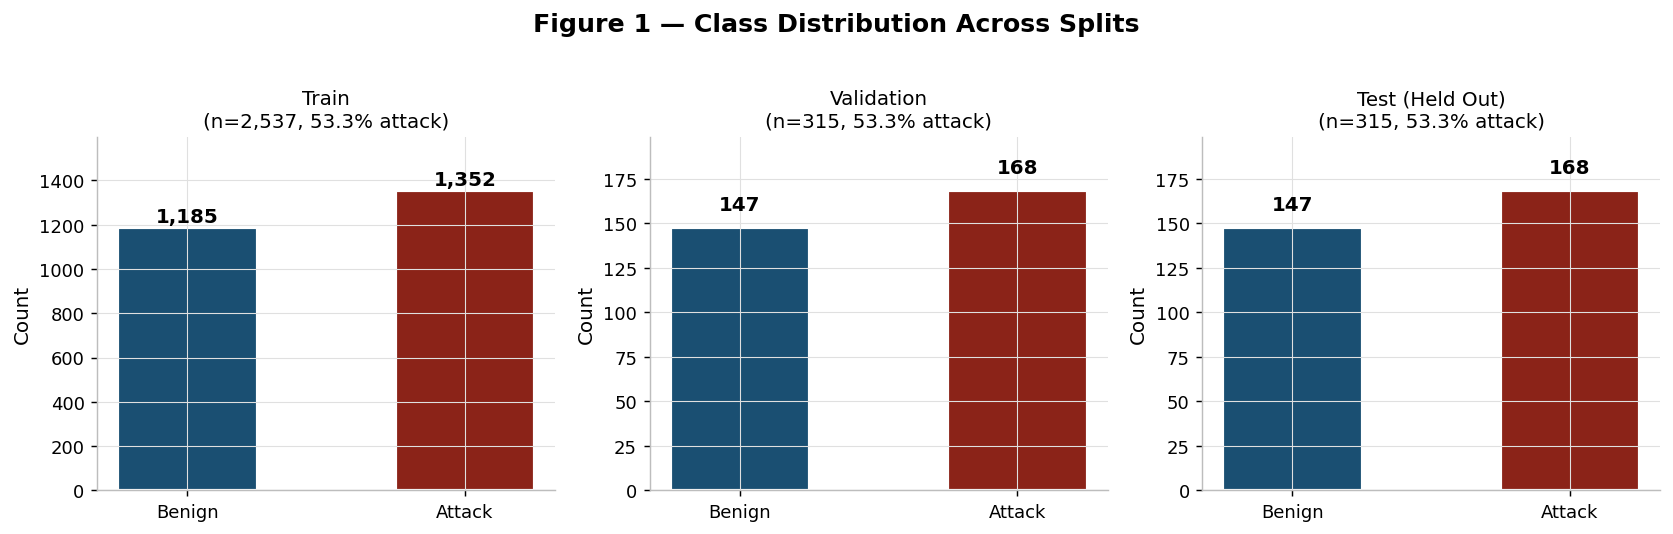

Saved → pair_classifier_plots/fig1_class_distribution.png


In [3]:
# Figure 1: Class Distribution 
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Figure 1 — Class Distribution Across Splits', fontsize=14, fontweight='bold', y=1.02)

for ax, (df, title) in zip(axes, [
    (train_df, 'Train'), (val_df, 'Validation'), (test_df, 'Test (Held Out)')
]):
    counts = df['label'].value_counts().sort_index()
    bars = ax.bar(
        ['Benign', 'Attack'], [counts.get(0,0), counts.get(1,0)],
        color=[C['benign'], C['attack']], width=0.5, edgecolor='white', linewidth=1.2
    )
    for bar, count in zip(bars, [counts.get(0,0), counts.get(1,0)]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    total = len(df)
    pct_attack = counts.get(1,0) / total * 100
    ax.set_title(f'{title}\n(n={total:,}, {pct_attack:.1f}% attack)', fontsize=11)
    ax.set_ylim(0, max(counts.values) * 1.18)
    ax.set_ylabel('Count')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'fig1_class_distribution.png')
plt.show()
print(f'Saved → pair_classifier_plots/fig1_class_distribution.png')

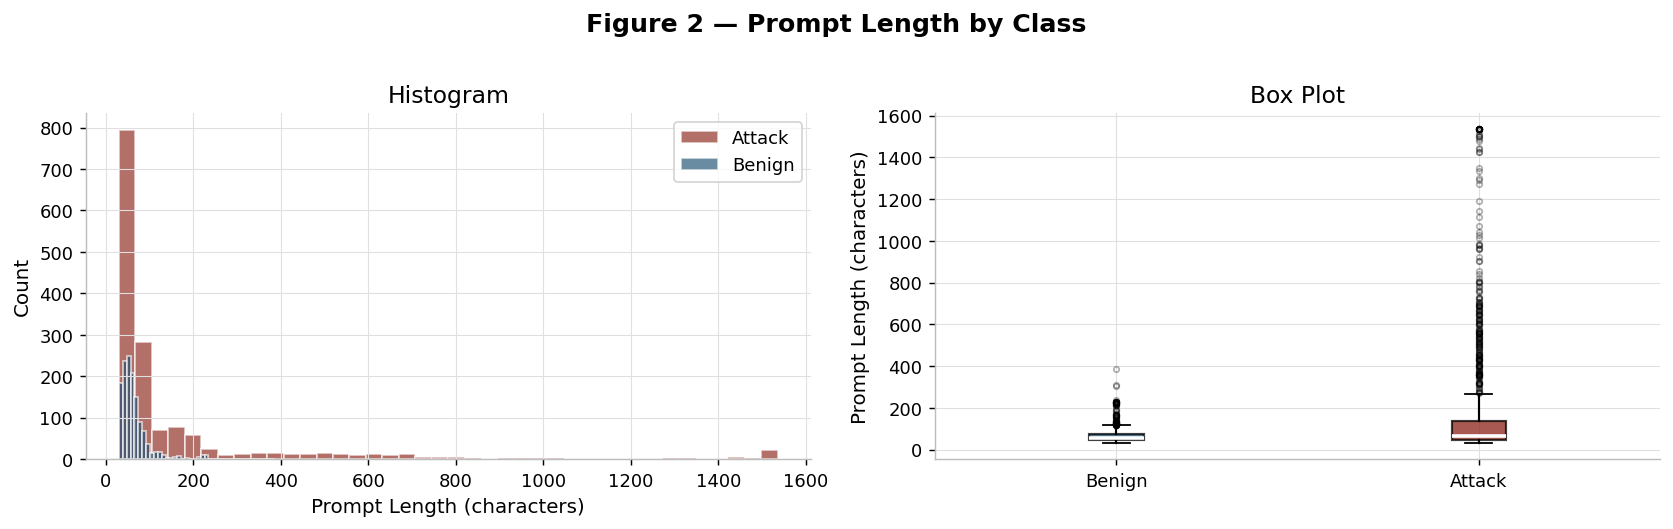

Saved → pair_classifier_plots/fig2_prompt_length.png

Prompt length stats:
            mean   50%   min     max
label_str                           
Attack     162.8  66.0  30.0  1536.0
Benign      64.7  56.0  30.0   386.0


In [4]:
# Figure 2: Prompt Length Distribution 
all_df = pd.concat([train_df, val_df], ignore_index=True)
all_df['prompt_len'] = all_df['prompt'].str.len()
all_df['label_str']  = all_df['label'].map({1: 'Attack', 0: 'Benign'})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Figure 2 — Prompt Length by Class', fontsize=14, fontweight='bold', y=1.01)

for label, color, name in [(1, C['attack'], 'Attack'), (0, C['benign'], 'Benign')]:
    subset = all_df[all_df['label'] == label]['prompt_len']
    axes[0].hist(subset, bins=40, alpha=0.65, color=color, label=name, edgecolor='white')
axes[0].set_xlabel('Prompt Length (characters)')
axes[0].set_ylabel('Count')
axes[0].set_title('Histogram')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

bp = axes[1].boxplot(
    [all_df[all_df['label']==0]['prompt_len'], all_df[all_df['label']==1]['prompt_len']],
    labels=['Benign', 'Attack'],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    boxprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.3),
)
for patch, color in zip(bp['boxes'], [C['benign'], C['attack']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_ylabel('Prompt Length (characters)')
axes[1].set_title('Box Plot')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'fig2_prompt_length.png')
plt.show()
print('Saved → pair_classifier_plots/fig2_prompt_length.png')
print('\nPrompt length stats:')
print(all_df.groupby('label_str')['prompt_len'].describe()[['mean','50%','min','max']].round(1))

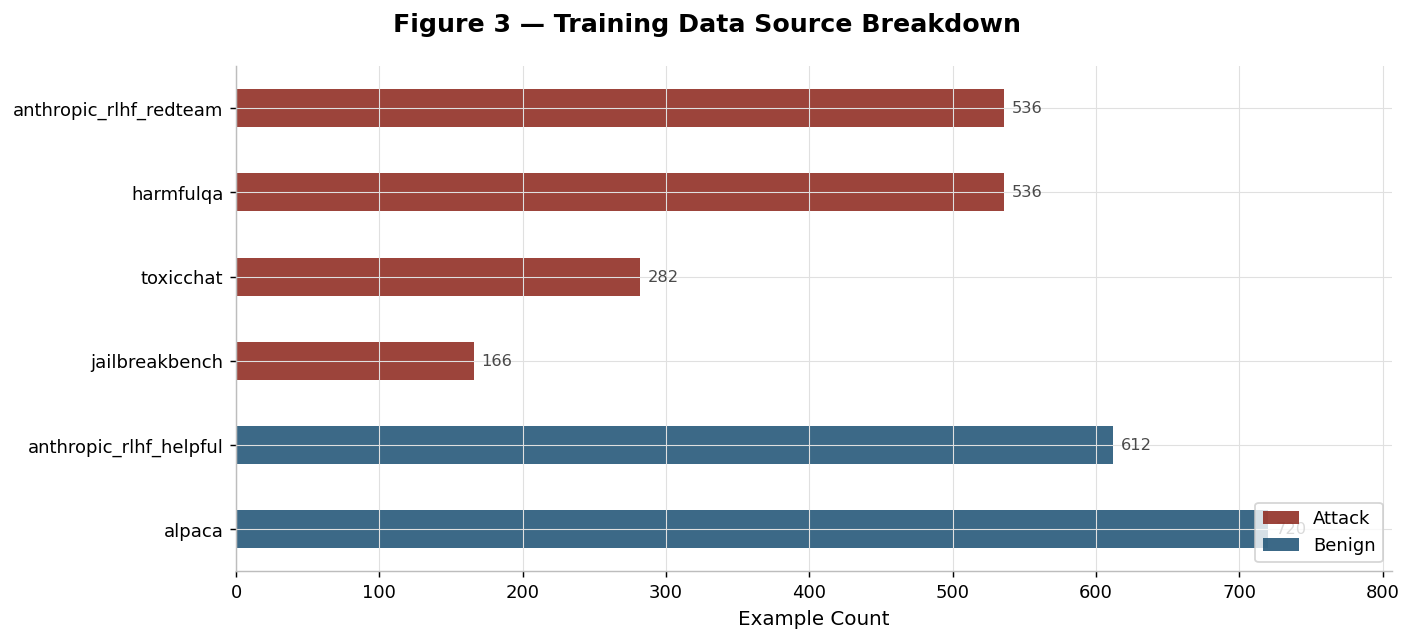

Saved → pair_classifier_plots/fig3_source_breakdown.png


In [5]:
#Figure 3: Source Breakdown 
src_stats = all_df.groupby(['source','label_str']).size().unstack(fill_value=0)
src_stats = src_stats.reindex(columns=['Attack','Benign'], fill_value=0)
src_stats = src_stats.sort_values('Attack', ascending=True)

fig, ax = plt.subplots(figsize=(11, 5))
fig.suptitle('Figure 3 — Training Data Source Breakdown', fontsize=14, fontweight='bold')

y = np.arange(len(src_stats))
ax.barh(y, src_stats['Attack'], color=C['attack'], alpha=0.85, label='Attack',  height=0.45)
ax.barh(y, src_stats['Benign'], color=C['benign'], alpha=0.85, label='Benign',  height=0.45,
        left=src_stats['Attack'])

for i, (a, b) in enumerate(zip(src_stats['Attack'], src_stats['Benign'])):
    ax.text(a + b + 5, i, f'{int(a+b):,}', va='center', fontsize=9, color=C['neutral'])

ax.set_yticks(y)
ax.set_yticklabels(src_stats.index, fontsize=10)
ax.set_xlabel('Example Count')
ax.legend(loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, src_stats[['Attack','Benign']].sum(axis=1).max() * 1.12)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'fig3_source_breakdown.png')
plt.show()
print('Saved → pair_classifier_plots/fig3_source_breakdown.png')

## 2. Feature Extraction — Sentence Embeddings

We use `sentence-transformers/all-MiniLM-L6-v2` (22 MB, CPU-optimized) to encode each prompt into a 384-dimensional dense vector. This captures semantic meaning rather than surface tokens, making it sensitive to intent rather than phrasing.

In [6]:
from sentence_transformers import SentenceTransformer

EMBED_MODEL = 'sentence-transformers/all-MiniLM-L6-v2'
embedder = SentenceTransformer(EMBED_MODEL)

print(f'Model loaded: {EMBED_MODEL}')
print(f'Embedding dim: {embedder.get_sentence_embedding_dimension()}')
print(f'Encoding {len(train_df)+len(val_df)+len(test_df):,} prompts...')

X_train = embedder.encode(train_df['prompt'].tolist(), batch_size=64,show_progress_bar=True, normalize_embeddings=True)
X_val   = embedder.encode(val_df['prompt'].tolist(),   batch_size=64, show_progress_bar=True, normalize_embeddings=True)
X_test  = embedder.encode(test_df['prompt'].tolist(),  batch_size=64,show_progress_bar=True, normalize_embeddings=True)

y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values

print(f'\nX_train: {X_train.shape}')
print(f'X_val  : {X_val.shape}')
print(f'X_test : {X_test.shape}')

Model loaded: sentence-transformers/all-MiniLM-L6-v2
Embedding dim: 384
Encoding 3,167 prompts...


Batches: 100%|██████████| 5/5 [00:01<00:00,  3.13it/s]


X_train: (2537, 384)
X_val  : (315, 384)
X_test : (315, 384)


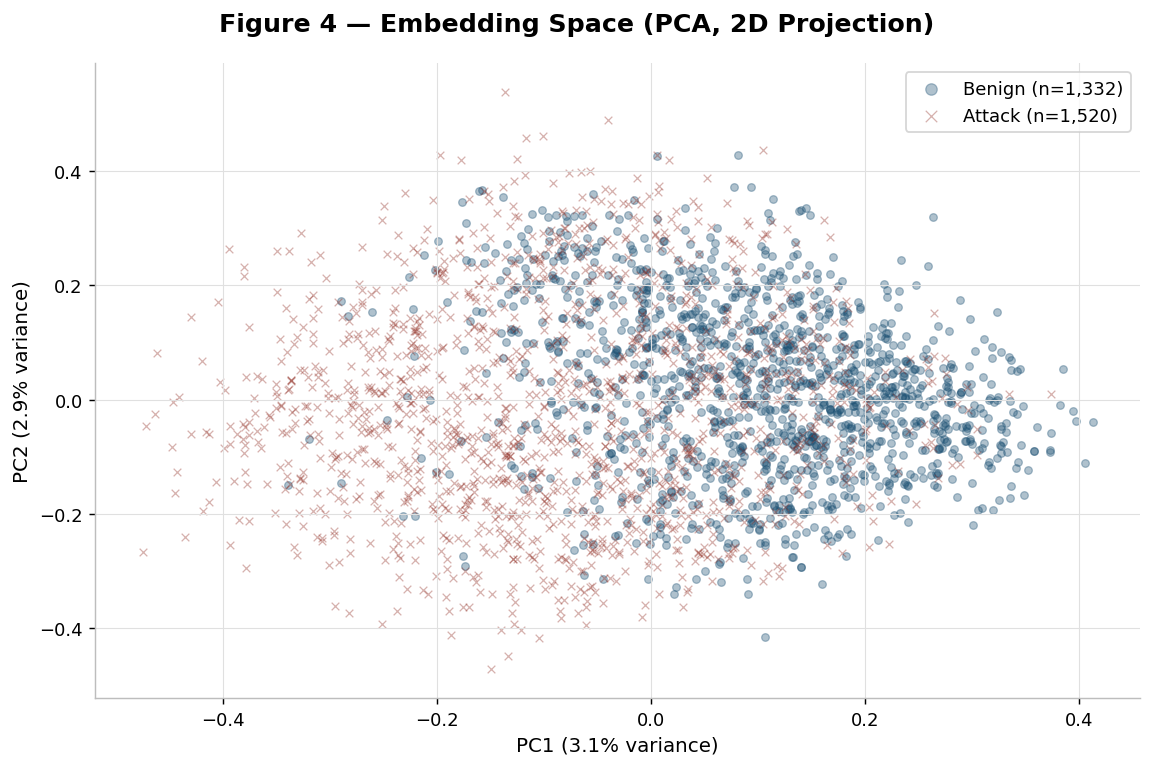

Saved → pair_classifier_plots/fig4_embedding_pca.png
Total variance explained: 6.1%


In [7]:
# Figure 4: Embedding Space (PCA) 
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_all_2d = pca.fit_transform(np.vstack([X_train, X_val]))
y_all     = np.concatenate([y_train, y_val])

fig, ax = plt.subplots(figsize=(9, 6))
fig.suptitle('Figure 4 — Embedding Space (PCA, 2D Projection)', fontsize=14, fontweight='bold')

for label, color, name, marker in [
    (0, C['benign'], 'Benign', 'o'),
    (1, C['attack'], 'Attack', 'x'),
]:
    mask = y_all == label
    ax.scatter(X_all_2d[mask, 0], X_all_2d[mask, 1],
               c=color, alpha=0.35, s=18, marker=marker, label=f'{name} (n={mask.sum():,})',
               linewidths=0.7)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(markerscale=1.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'fig4_embedding_pca.png')
plt.show()
print('Saved → pair_classifier_plots/fig4_embedding_pca.png')
print(f'Total variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%')

## 3. Model Training & Comparison

We compare three classifiers on top of sentence embeddings. The best model (by F1 on validation) is selected for deployment.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score,
    precision_recall_curve, roc_curve,
    confusion_matrix, f1_score, precision_score, recall_score
)

models = {
    'Logistic Regression': LogisticRegression(
        C=4.0, max_iter=1000, class_weight='balanced', solver='lbfgs', random_state=42
    ),
    'Linear SVM': CalibratedClassifierCV(
        LinearSVC(C=1.0, max_iter=2000, class_weight='balanced', random_state=42)
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),
        eval_metric='logloss', random_state=42, verbosity=0,
    ),
}

results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_val)[:, 1]
    y_pred = (y_prob >= 0.50).astype(int)

    rec  = recall_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    f1   = f1_score(y_val, y_pred)
    auc  = roc_auc_score(y_val, y_prob)
    fp   = ((y_pred == 1) & (y_val == 0)).sum()
    tn   = ((y_pred == 0) & (y_val == 0)).sum()
    fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    results[name] = {'Recall': rec, 'Precision': prec, 'F1': f1, 'AUC-ROC': auc, 'FPR': fpr}
    trained_models[name] = (model, y_prob)
    print(f'{name:<22s}  Recall={rec*100:.1f}%  Prec={prec*100:.1f}%  F1={f1*100:.1f}%  AUC={auc:.3f}  FPR={fpr*100:.1f}%')

results_df = pd.DataFrame(results).T
best_model_name = results_df['F1'].idxmax()
print(f'\nBest model (by F1): {best_model_name}')

Logistic Regression     Recall=89.3%  Prec=92.6%  F1=90.9%  AUC=0.959  FPR=8.2%
Linear SVM              Recall=91.1%  Prec=91.6%  F1=91.3%  AUC=0.961  FPR=9.5%
XGBoost                 Recall=86.9%  Prec=93.0%  F1=89.8%  AUC=0.958  FPR=7.5%

Best model (by F1): Linear SVM


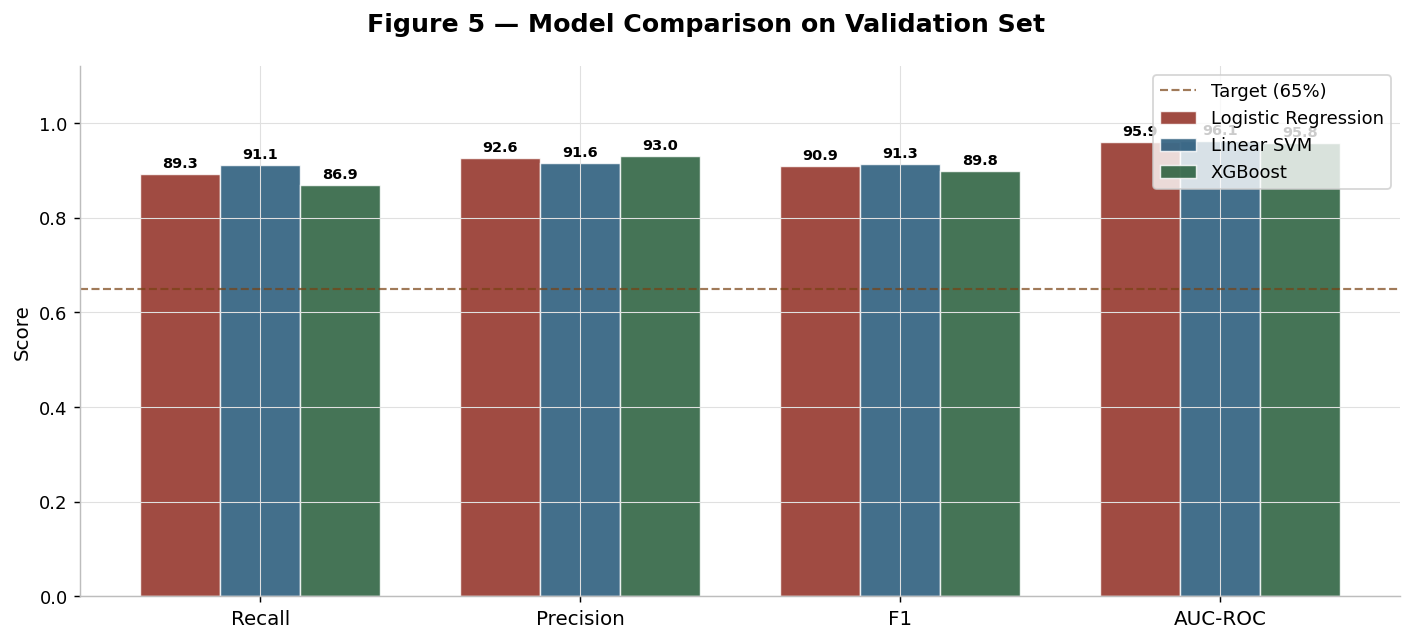

Saved → pair_classifier_plots/fig5_model_comparison.png


In [9]:
# Figure 5: Model Comparison Bar Chart 
metrics_to_plot = ['Recall', 'Precision', 'F1', 'AUC-ROC']
model_names     = list(results.keys())
x = np.arange(len(metrics_to_plot))
width = 0.25
bar_colors = [C['attack'], C['benign'], C['good']]

fig, ax = plt.subplots(figsize=(11, 5))
fig.suptitle('Figure 5 — Model Comparison on Validation Set', fontsize=14, fontweight='bold')

for i, (name, color) in enumerate(zip(model_names, bar_colors)):
    vals = [results[name][m] for m in metrics_to_plot]
    bars = ax.bar(x + i*width - width, vals, width, label=name,
                  color=color, alpha=0.82, edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f'{v*100:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.12)
ax.axhline(0.65, color=C['warn'], linewidth=1.2, linestyle='--', alpha=0.7, label='Target (65%)')
ax.legend(loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'fig5_model_comparison.png')
plt.show()
print('Saved → pair_classifier_plots/fig5_model_comparison.png')

## 4. Best Model — Deep Analysis

In [10]:
best_clf, best_probs = trained_models[best_model_name]
best_pred = (best_probs >= 0.50).astype(int)

print(f'Best model: {best_model_name}')
print()
print(classification_report(y_val, best_pred, target_names=['Benign', 'Attack']))

Best model: Linear SVM

              precision    recall  f1-score   support

      Benign       0.90      0.90      0.90       147
      Attack       0.92      0.91      0.91       168

    accuracy                           0.91       315
   macro avg       0.91      0.91      0.91       315
weighted avg       0.91      0.91      0.91       315



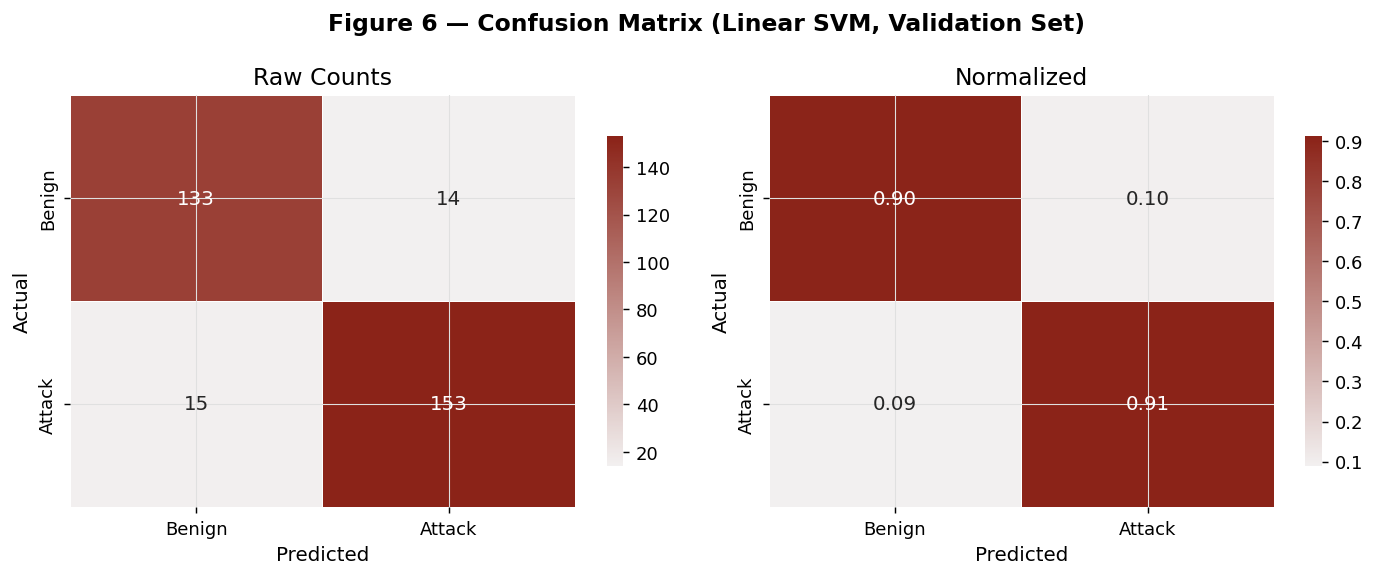

Saved → pair_classifier_plots/fig6_confusion_matrix.png


In [11]:
# Figure 6: Confusion Matrix
cm = confusion_matrix(y_val, best_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle(f'Figure 6 — Confusion Matrix ({best_model_name}, Validation Set)',
             fontsize=13, fontweight='bold')

for ax, data, fmt, title in [
    (axes[0], cm,      'd',    'Raw Counts'),
    (axes[1], cm_norm, '.2f',  'Normalized'),
]:
    cmap = sns.light_palette(C['attack'], as_cmap=True)
    sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap, ax=ax,
                xticklabels=['Benign','Attack'], yticklabels=['Benign','Attack'],
                linewidths=0.5, linecolor='white', cbar_kws={'shrink': 0.8})
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(title)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'fig6_confusion_matrix.png')
plt.show()
print('Saved → pair_classifier_plots/fig6_confusion_matrix.png')

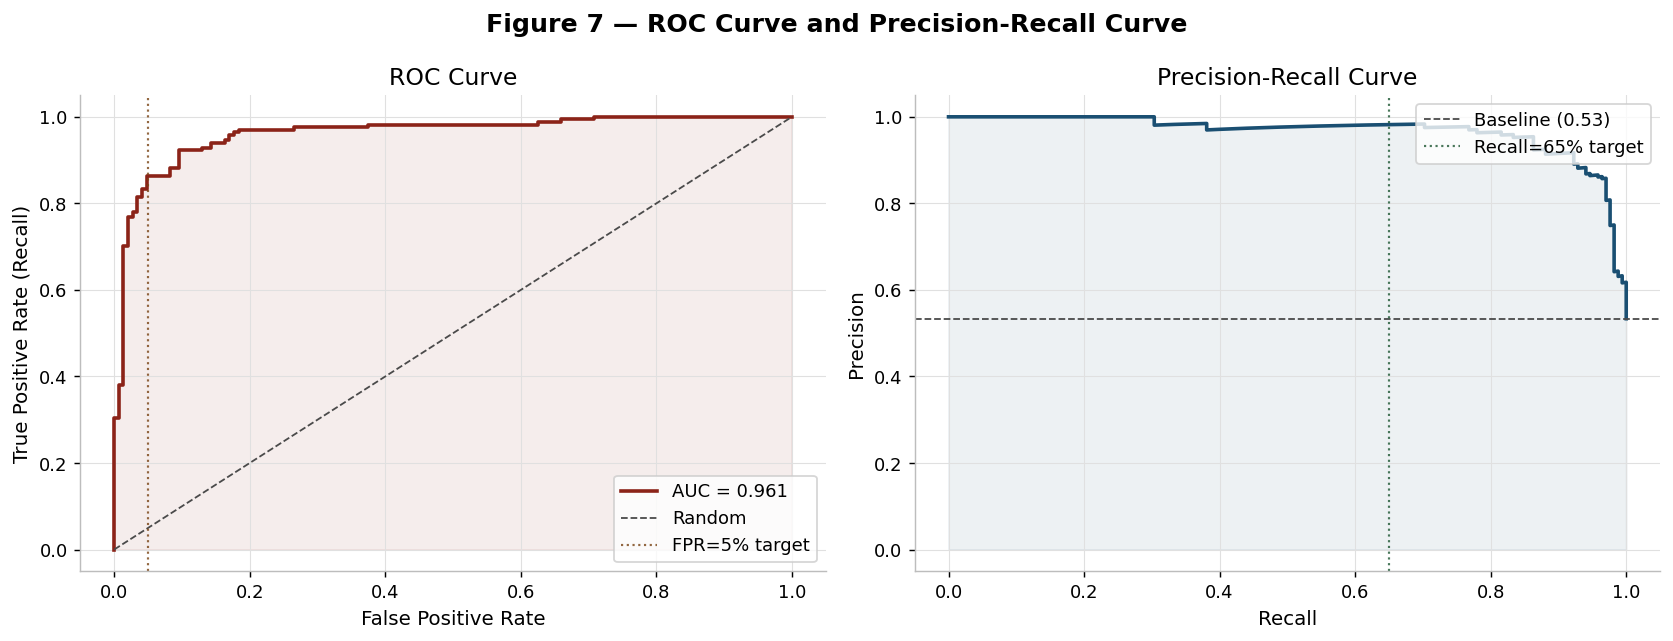

Saved → pair_classifier_plots/fig7_roc_pr.png


In [12]:
# Figure 7: ROC Curve + Precision-Recall Curve
fpr_curve, tpr_curve, _            = roc_curve(y_val, best_probs)
prec_curve, rec_curve, thresh_pr   = precision_recall_curve(y_val, best_probs)
auc_roc = roc_auc_score(y_val, best_probs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 7 — ROC Curve and Precision-Recall Curve', fontsize=14, fontweight='bold')

# ROC
axes[0].plot(fpr_curve, tpr_curve, color=C['attack'], lw=2, label=f'AUC = {auc_roc:.3f}')
axes[0].plot([0,1],[0,1], color=C['neutral'], lw=1, linestyle='--', label='Random')
axes[0].fill_between(fpr_curve, tpr_curve, alpha=0.08, color=C['attack'])
axes[0].axvline(0.05, color=C['warn'], lw=1.2, linestyle=':', alpha=0.8, label='FPR=5% target')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# PR
axes[1].plot(rec_curve, prec_curve, color=C['benign'], lw=2)
axes[1].fill_between(rec_curve, prec_curve, alpha=0.08, color=C['benign'])
baseline = y_val.mean()
axes[1].axhline(baseline, color=C['neutral'], lw=1, linestyle='--', label=f'Baseline ({baseline:.2f})')
axes[1].axvline(0.65, color=C['good'], lw=1.2, linestyle=':', alpha=0.8, label='Recall=65% target')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='upper right')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'fig7_roc_pr.png')
plt.show()
print('Saved → pair_classifier_plots/fig7_roc_pr.png')

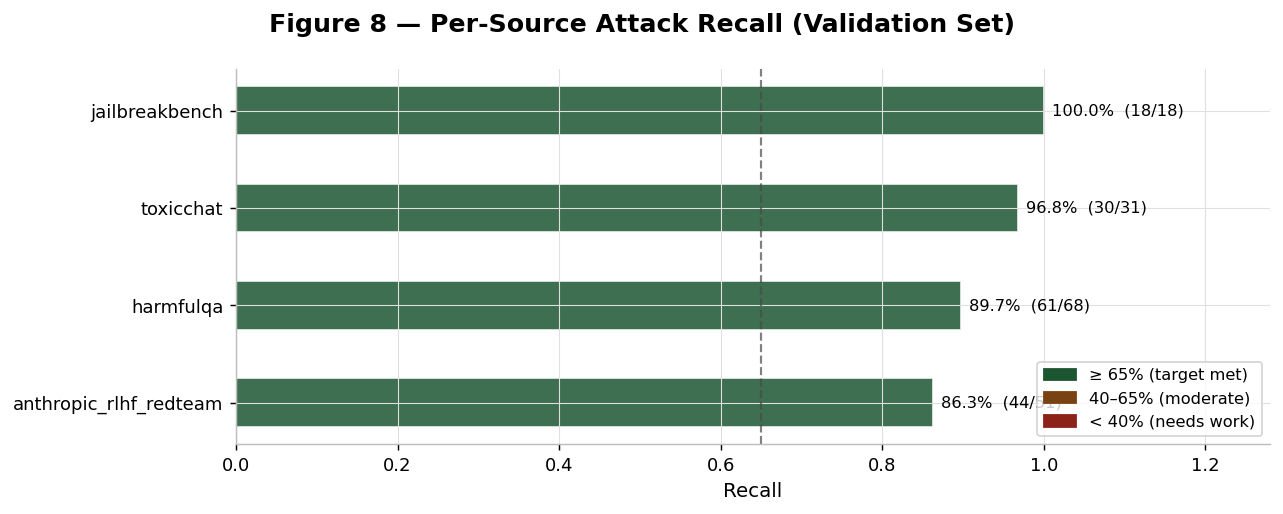

Saved → pair_classifier_plots/fig8_per_source_recall.png


In [13]:
# Figure 8: Per-Source Recall Breakdown 
val_df_copy = val_df.copy()
val_df_copy['pred']  = best_pred
val_df_copy['proba'] = best_probs

attack_val = val_df_copy[val_df_copy['label'] == 1]
src_recall = attack_val.groupby('source').apply(
    lambda g: pd.Series({'total': len(g), 'detected': g['pred'].sum(), 'recall': g['pred'].mean()})
).reset_index().sort_values('recall', ascending=True)

fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle('Figure 8 — Per-Source Attack Recall (Validation Set)', fontsize=14, fontweight='bold')

colors = [C['good'] if r >= 0.65 else C['warn'] if r >= 0.40 else C['attack']
          for r in src_recall['recall']]
bars = ax.barh(src_recall['source'], src_recall['recall'],color=colors, alpha=0.85, edgecolor='white', height=0.5)
for bar, row in zip(bars, src_recall.itertuples()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,f'{row.recall*100:.1f}%  ({int(row.detected)}/{int(row.total)})',va='center', fontsize=9)

ax.axvline(0.65, color=C['neutral'], lw=1.2, linestyle='--', alpha=0.7)
ax.set_xlabel('Recall')
ax.set_xlim(0, 1.28)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
patches = [
    mpatches.Patch(color=C['good'],   label='≥ 65% (target met)'),
    mpatches.Patch(color=C['warn'],   label='40–65% (moderate)'),
    mpatches.Patch(color=C['attack'], label='< 40% (needs work)'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'fig8_per_source_recall.png')
plt.show()
print('Saved → pair_classifier_plots/fig8_per_source_recall.png')

## 5. Threshold Optimization

The default threshold of 0.50 may not be optimal. We sweep thresholds and find the operating point that maximizes F1 while keeping FPR ≤ 5%.

In [14]:
thresholds = np.arange(0.10, 0.95, 0.01)
sweep = []
for t in thresholds:
    pred = (best_probs >= t).astype(int)
    rec  = recall_score(y_val, pred, zero_division=0)
    prec = precision_score(y_val, pred, zero_division=0)
    f1   = f1_score(y_val, pred, zero_division=0)
    fp   = ((pred==1) & (y_val==0)).sum()
    tn   = ((pred==0) & (y_val==0)).sum()
    fpr  = fp / (fp + tn) if (fp+tn) > 0 else 0.0
    sweep.append({'threshold': t, 'recall': rec, 'precision': prec, 'f1': f1, 'fpr': fpr})

sweep_df = pd.DataFrame(sweep)

# Best threshold: max F1 where FPR ≤ 5%
fpr_constrained = sweep_df[sweep_df['fpr'] <= 0.05]
if len(fpr_constrained) > 0:
    best_row = fpr_constrained.loc[fpr_constrained['f1'].idxmax()]
else:
    best_row = sweep_df.loc[sweep_df['f1'].idxmax()]

OPTIMAL_THRESHOLD = float(best_row['threshold'])
print(f'Optimal threshold (max F1 @ FPR≤5%): {OPTIMAL_THRESHOLD:.2f}')
print(f'  Recall    : {best_row["recall"]*100:.1f}%')
print(f'  Precision : {best_row["precision"]*100:.1f}%')
print(f'  F1        : {best_row["f1"]*100:.1f}%')
print(f'  FPR       : {best_row["fpr"]*100:.1f}%')

Optimal threshold (max F1 @ FPR≤5%): 0.60
  Recall    : 86.3%
  Precision : 95.4%
  F1        : 90.6%
  FPR       : 4.8%


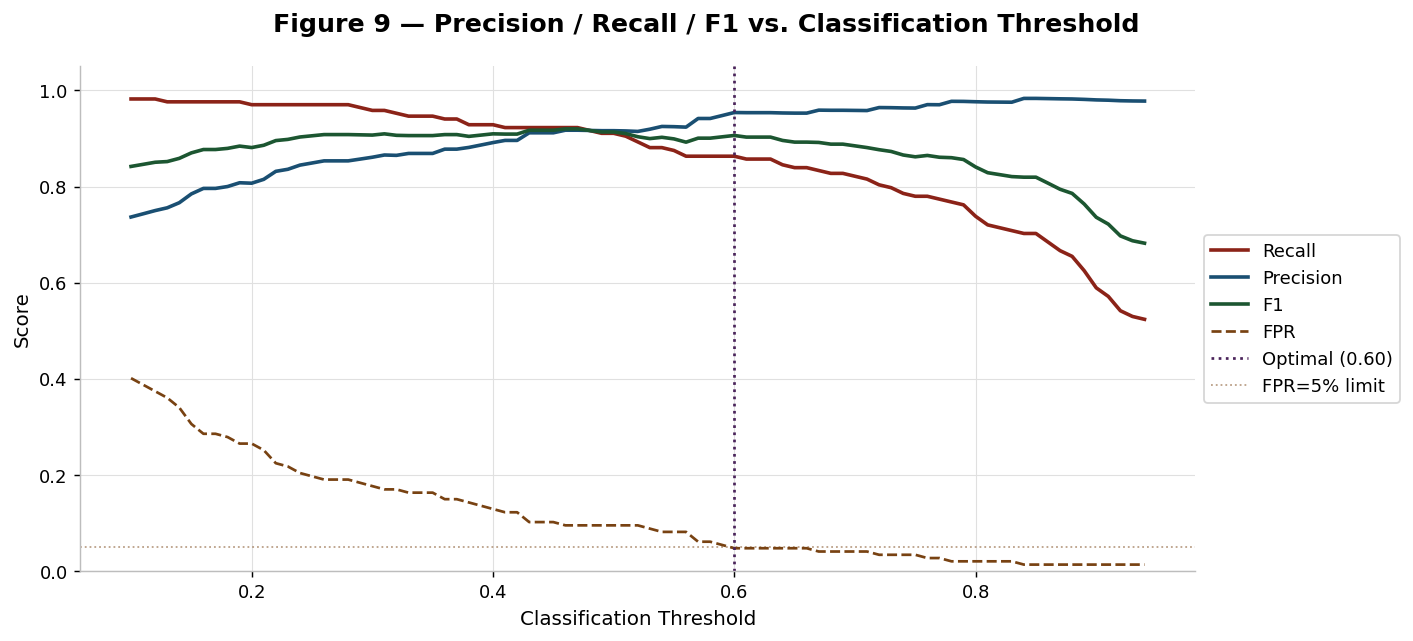

Saved → pair_classifier_plots/fig9_threshold_sweep.png


In [15]:
# Figure 9: Threshold Sweep 
fig, ax = plt.subplots(figsize=(11, 5))
fig.suptitle('Figure 9 — Precision / Recall / F1 vs. Classification Threshold',
             fontsize=14, fontweight='bold')

ax.plot(sweep_df['threshold'], sweep_df['recall'],    color=C['attack'],    lw=2, label='Recall')
ax.plot(sweep_df['threshold'], sweep_df['precision'], color=C['benign'],    lw=2, label='Precision')
ax.plot(sweep_df['threshold'], sweep_df['f1'],        color=C['good'],      lw=2, label='F1')
ax.plot(sweep_df['threshold'], sweep_df['fpr'],       color=C['warn'],      lw=1.5, linestyle='--', label='FPR')
ax.axvline(OPTIMAL_THRESHOLD, color=C['highlight'],   lw=1.5, linestyle=':',
           label=f'Optimal ({OPTIMAL_THRESHOLD:.2f})')
ax.axhline(0.05, color=C['warn'], lw=1, linestyle=':', alpha=0.5, label='FPR=5% limit')

ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'fig9_threshold_sweep.png')
plt.show()
print('Saved → pair_classifier_plots/fig9_threshold_sweep.png')

## 6. Final Evaluation — Held-Out Test Set

> **Important:** This cell uses the test set that was locked away during all training and validation. These numbers are the ones reported in the paper.

In [16]:
y_test_prob = best_clf.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= OPTIMAL_THRESHOLD).astype(int)

tp = int(((y_test_pred==1) & (y_test==1)).sum())
fn = int(((y_test_pred==0) & (y_test==1)).sum())
fp = int(((y_test_pred==1) & (y_test==0)).sum())
tn = int(((y_test_pred==0) & (y_test==0)).sum())

test_recall = tp / (tp + fn) if (tp+fn) > 0 else 0
test_prec   = tp / (tp + fp) if (tp+fp) > 0 else 0
test_f1     = 2 * test_prec * test_recall / (test_prec + test_recall) if (test_prec+test_recall) > 0 else 0
test_fpr    = fp / (fp + tn) if (fp+tn) > 0 else 0
test_auc    = roc_auc_score(y_test, y_test_prob)

print('=' * 50)
print('  FINAL TEST SET RESULTS (Held-Out)') 
print('=' * 50)
print(f'  Model     : {best_model_name}')
print(f'  Threshold : {OPTIMAL_THRESHOLD:.2f}')
print(f'  Recall    : {test_recall*100:.1f}%')
print(f'  Precision : {test_prec*100:.1f}%')
print(f'  F1        : {test_f1*100:.1f}%')
print(f'  FPR       : {test_fpr*100:.1f}%')
print(f'  AUC-ROC   : {test_auc:.3f}')
print(f'  TP={tp}  FN={fn}  FP={fp}  TN={tn}')
print('=' * 50)

target_met = test_recall >= 0.65 and test_fpr <= 0.05
print(f'\n  Deployment target (Recall≥65%, FPR≤5%): {"MET" if target_met else "NOT MET"}')

  FINAL TEST SET RESULTS (Held-Out)
  Model     : Linear SVM
  Threshold : 0.60
  Recall    : 83.9%
  Precision : 96.6%
  F1        : 89.8%
  FPR       : 3.4%
  AUC-ROC   : 0.966
  TP=141  FN=27  FP=5  TN=142

  Deployment target (Recall≥65%, FPR≤5%): MET


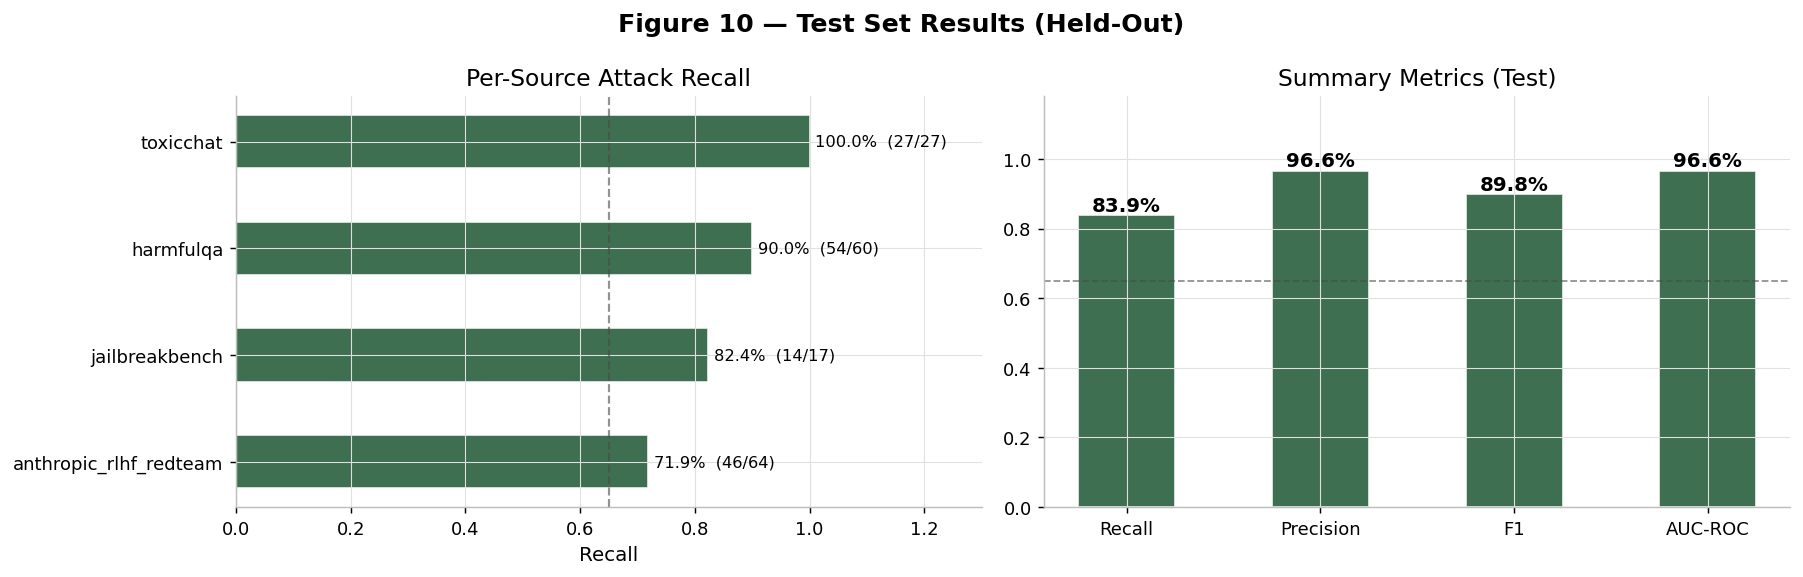

Saved → pair_classifier_plots/fig10_test_results.png


In [17]:
# Figure 10: Test Set — Per-Source Recall + Summary
test_df_copy = test_df.copy()
test_df_copy['pred']  = y_test_pred
test_df_copy['proba'] = y_test_prob

attack_test = test_df_copy[test_df_copy['label'] == 1]
src_test = attack_test.groupby('source').apply(
    lambda g: pd.Series({'total': len(g), 'detected': g['pred'].sum(), 'recall': g['pred'].mean()})
).reset_index().sort_values('recall', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle('Figure 10 — Test Set Results (Held-Out)', fontsize=14, fontweight='bold')

colors_t = [C['good'] if r >= 0.65 else C['warn'] if r >= 0.40 else C['attack']
            for r in src_test['recall']]
bars = axes[0].barh(src_test['source'], src_test['recall'],
                    color=colors_t, alpha=0.85, edgecolor='white', height=0.5)
for bar, row in zip(bars, src_test.itertuples()):
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{row.recall*100:.1f}%  ({int(row.detected)}/{int(row.total)})',
                 va='center', fontsize=9)
axes[0].axvline(0.65, color=C['neutral'], lw=1.2, linestyle='--', alpha=0.6)
axes[0].set_xlabel('Recall')
axes[0].set_title('Per-Source Attack Recall')
axes[0].set_xlim(0, 1.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

metric_names = ['Recall', 'Precision', 'F1', 'AUC-ROC']
metric_vals  = [test_recall, test_prec, test_f1, test_auc]
bar_colors_m = [C['good'] if v >= 0.65 else C['warn'] for v in metric_vals]
bars2 = axes[1].bar(metric_names, metric_vals, color=bar_colors_m,
                    alpha=0.85, edgecolor='white', width=0.5)
for bar, v in zip(bars2, metric_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                 f'{v*100:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[1].set_ylim(0, 1.18)
axes[1].axhline(0.65, color=C['neutral'], lw=1, linestyle='--', alpha=0.6)
axes[1].set_title('Summary Metrics (Test)')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'fig10_test_results.png')
plt.show()
print('Saved → pair_classifier_plots/fig10_test_results.png')

## 7. Save Model for Deployment

In [18]:
import joblib
from datetime import datetime

clf_path  = MODELS_DIR / 'pair_intent_classifier.pkl'
meta_path = MODELS_DIR / 'pair_intent_meta.json'

joblib.dump(best_clf, clf_path)

meta = {
    'trained_at':        datetime.utcnow().strftime('%Y-%m-%dT%H:%M:%SZ'),
    'model_type':        best_model_name,
    'embed_model':       EMBED_MODEL,
    'embed_dim':         int(X_train.shape[1]),
    'threshold':         OPTIMAL_THRESHOLD,
    'train_size':        int(len(train_df)),
    'val_size':          int(len(val_df)),
    'test_size':         int(len(test_df)),
    'n_attack_train':    int(y_train.sum()),
    'n_benign_train':    int((y_train==0).sum()),
    'val_metrics': {
        'recall':    round(float(results[best_model_name]['Recall']), 4),
        'precision': round(float(results[best_model_name]['Precision']), 4),
        'f1':        round(float(results[best_model_name]['F1']), 4),
        'auc_roc':   round(float(results[best_model_name]['AUC-ROC']), 4),
        'fpr':       round(float(results[best_model_name]['FPR']), 4),
    },
    'test_metrics': {
        'recall':    round(test_recall, 4),
        'precision': round(test_prec, 4),
        'f1':        round(test_f1, 4),
        'auc_roc':   round(test_auc, 4),
        'fpr':       round(test_fpr, 4),
        'tp': tp, 'fn': fn, 'fp': fp, 'tn': tn,
    },
    'sources': train_df['source'].value_counts().to_dict(),
    'deployment_target_met': bool(target_met),
}

with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)

print(f'Classifier saved : {clf_path}')
print(f'Metadata saved   : {meta_path}')
print(f'\nEmbed model used : {EMBED_MODEL}')
print(f'(downloaded automatically by sentence-transformers on first use)')

Classifier saved : C:\Users\ASUS\Desktop\Failure_Intelligence_System\models\pair_intent_classifier.pkl
Metadata saved   : C:\Users\ASUS\Desktop\Failure_Intelligence_System\models\pair_intent_meta.json

Embed model used : sentence-transformers/all-MiniLM-L6-v2
(downloaded automatically by sentence-transformers on first use)
